# Fitting Io in the image plane

In [1]:
# jax ecosystem
import jax

jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_enable_x64", True)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots  # to use matplotlib style "science"

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/noob/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "AJQ4YHQH9TX":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"

source_name = "PDS70"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[17, 70] = 1
        file["BADPIX"].data[19, 53] = 1
        file["BADPIX"].data[5, 22] = 1
        file["BADPIX"].data[19, 41] = 1
        file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[76, 45] = 1
        file["BADPIX"].data[59, 30] = 1

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 65)

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}'
    )
    t0 = t


------------------------------

HD 228337 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785, Groups: 29, Ints: 418
TD-PDS-70 F480M, Dither 1/1, Roll 301.7deg, 50.5min, 2023-02-24 21:05:08.000, Groups: 96, Ints: 418


/home/max/miniforge3/envs/noob/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## Building the model

In [ ]:
source_size = 121  # pixels
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

# sci_fits = [dorito.model_fits.MCAFit(file, use_cov=True) for file in sci_files]
sci_fits = [amigo.model_fits.PointFit(file, use_cov=True) for file in sci_files]
# sci_fits = []
cal_fits = [amigo.model_fits.PointFit(file, use_cov=True) for file in cal_files]
fits = sci_fits + cal_fits

# building the model
model = amigo.core_models.AmigoModel(
    # model = dorito.models.MCAModel(
    exposures=fits,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(cache + "calibration.npy"),
    # param_initers={
    #     "distribution": np.ones((source_size, source_size)),
    #     "contrast": 0.949,
    # },
    # moat_width=1,
)

File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96



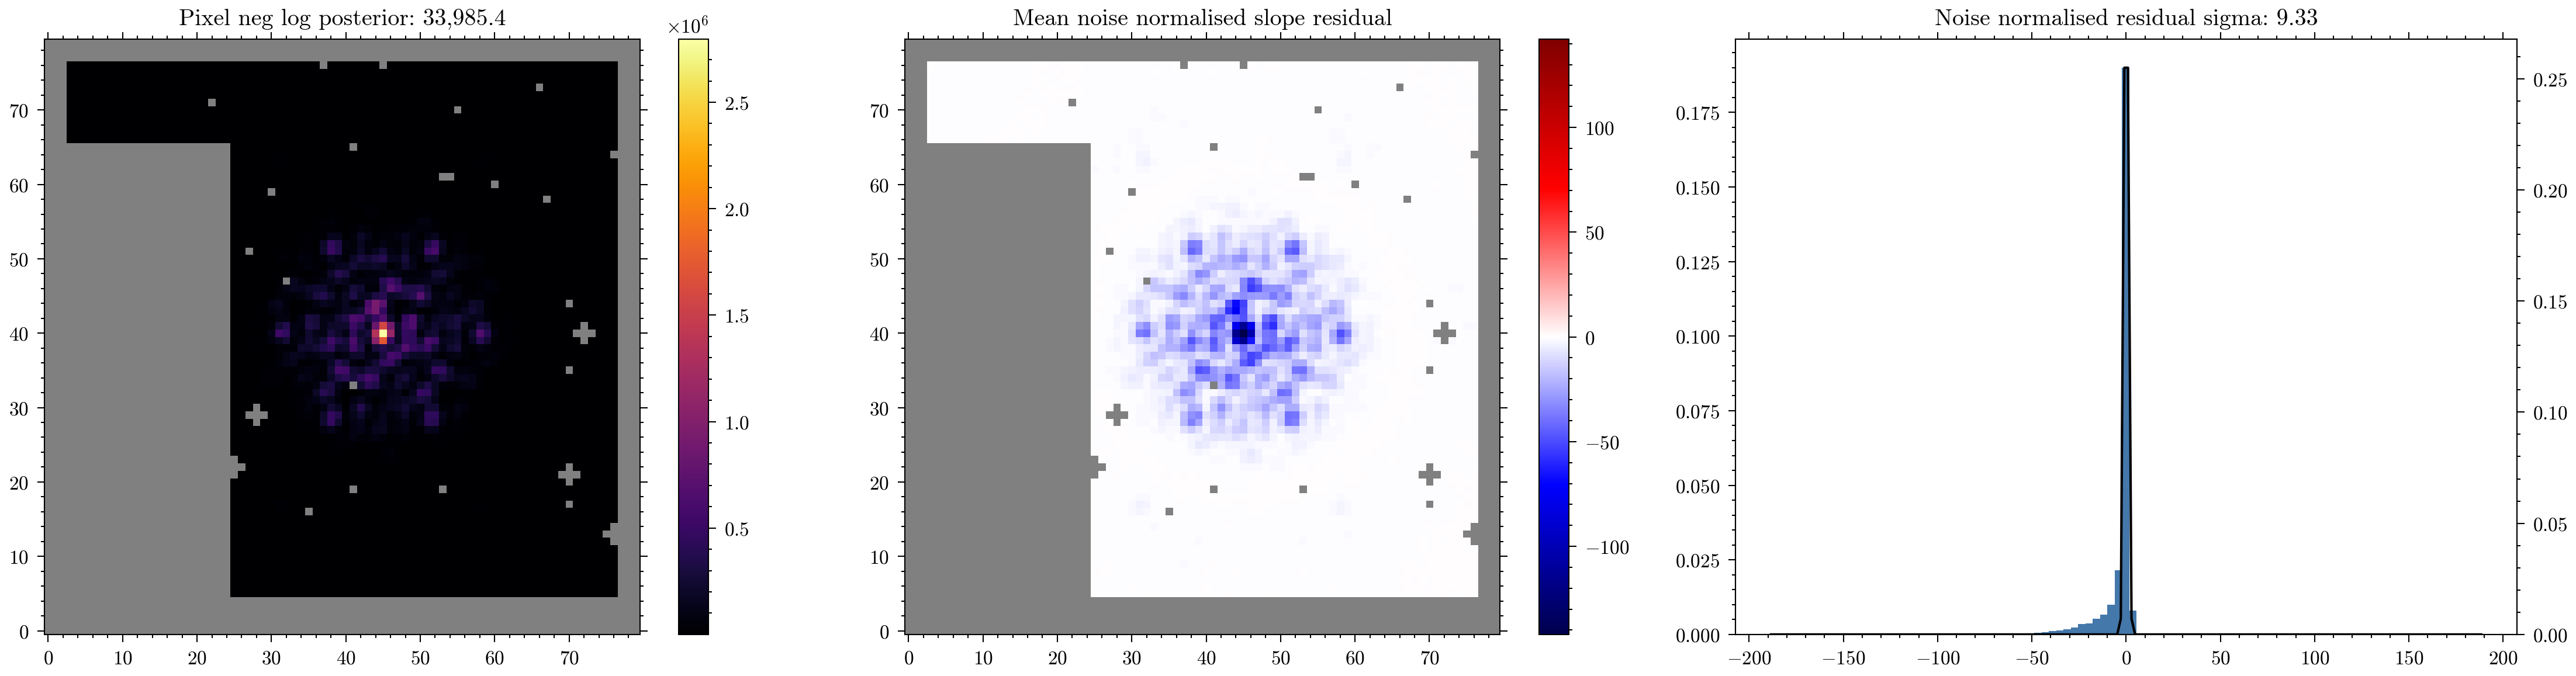

File 01242_004_02_03_1
Star HD 228337
Filter F480M
nints 418
ngroups 29



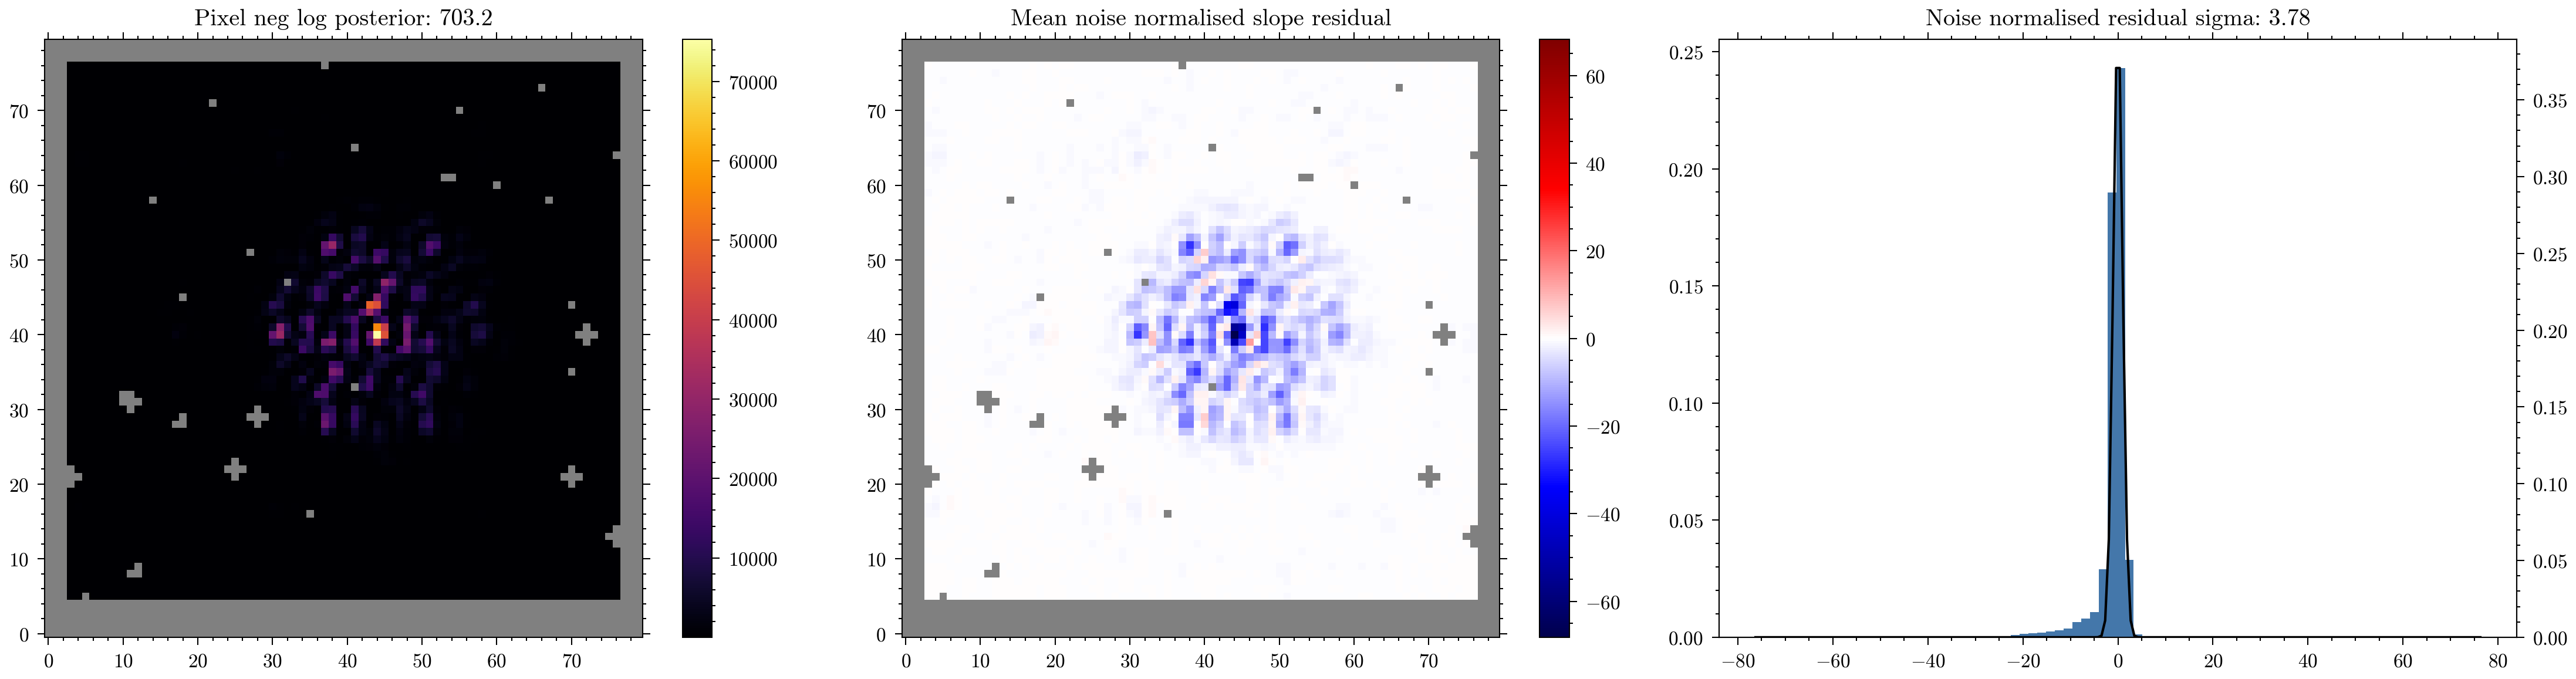

In [7]:
for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False)

## Optimisation Stage 1: Gradient Descent

In [8]:
pos_keys = []
spc_keys = []
for exp in fits:
    if not exp.calibrator:
        pos_keys.append(exp.map_param("positions"))
        spc_keys.append(exp.map_param("spectra"))


def norm_fn(model_params, args):
    params = model_params.params
    if "log_dist" in params.keys():

        for filt in params["log_dist"].keys():

            log_dist = params["log_dist"][filt]
            contrast = params["contrast"][filt]

            dist = 10**log_dist

            # normalising the distribution
            params["log_dist"][filt] = np.log10(dist * (1 - contrast) / dist.sum())

    if "spectra" in params.keys():
        spectra = jtu.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample


# def regularised_loss_fn(model, exp, args={"reg_func_dict": {}, "reg_dict": {}}):
#     # this is per exposure

#     # regular likelihood term
#     likelihood = -np.nanmean(exp.mv_zscore(model))

#     # grabbing and exponentiating log distributions
#     prior = apply_regularisers(model, exp, args) if not exp.calibrator else 0.0

#     return likelihood + prior, ()

In [10]:
n_epoch = 100

config = {
    "positions": sgd(3e-3, 0),
    "fluxes": sgd(5e-3, 0),
    "aberrations": sgd(5e-3, 4),
    "spectra": sgd(1e-2, 20),
    # "log_dist": adam(2e-1, 30),
    # "contrast": sgd(2e-6, 100),
    # "contrast": sgd(1e-6, 1000000),
    # "phases": sgd(1e-3, 20),
    # "amplitudes": sgd(1e-3, 20),
}


def grad_fn(model, grads, args):

    # Reduce spectra gradients for the science exposures
    if "spectra" in config.keys():
        grads = grads.multiply(spc_keys, 0.3)
    return grads, args


args = {
    "reg_dict": {
        # "L1": dorito.stats.L1_on_wavelets,
        # "L1": L1_REG,
        # "QV": dorito.stats.TSV,
        # 1e4: dorito.stats.TV,
        "ME": (5e-2, dorito.stats.ME),
    }
}

trainer = amigo.fitting.Trainer(
    # loss_fn=dorito.stats.ramp_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    # model.set("detector.ramp.bleed", False).set("params", params),
    model,
    fits,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys()],  # if p not in ["log_dist"]],
)

print("Number of exposures: ", len(fits))

# Train the model
# with jax.profiler.trace("/tmp/jax-trace", create_perfetto_link=True):
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
    # args=args,
)

Populating fishers...
Number of exposures:  2


  0%|          | 0/100 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 17,338.61
Estimated run time: 0:01:29
Full Time: 0:01:52
Final Loss: 107.10


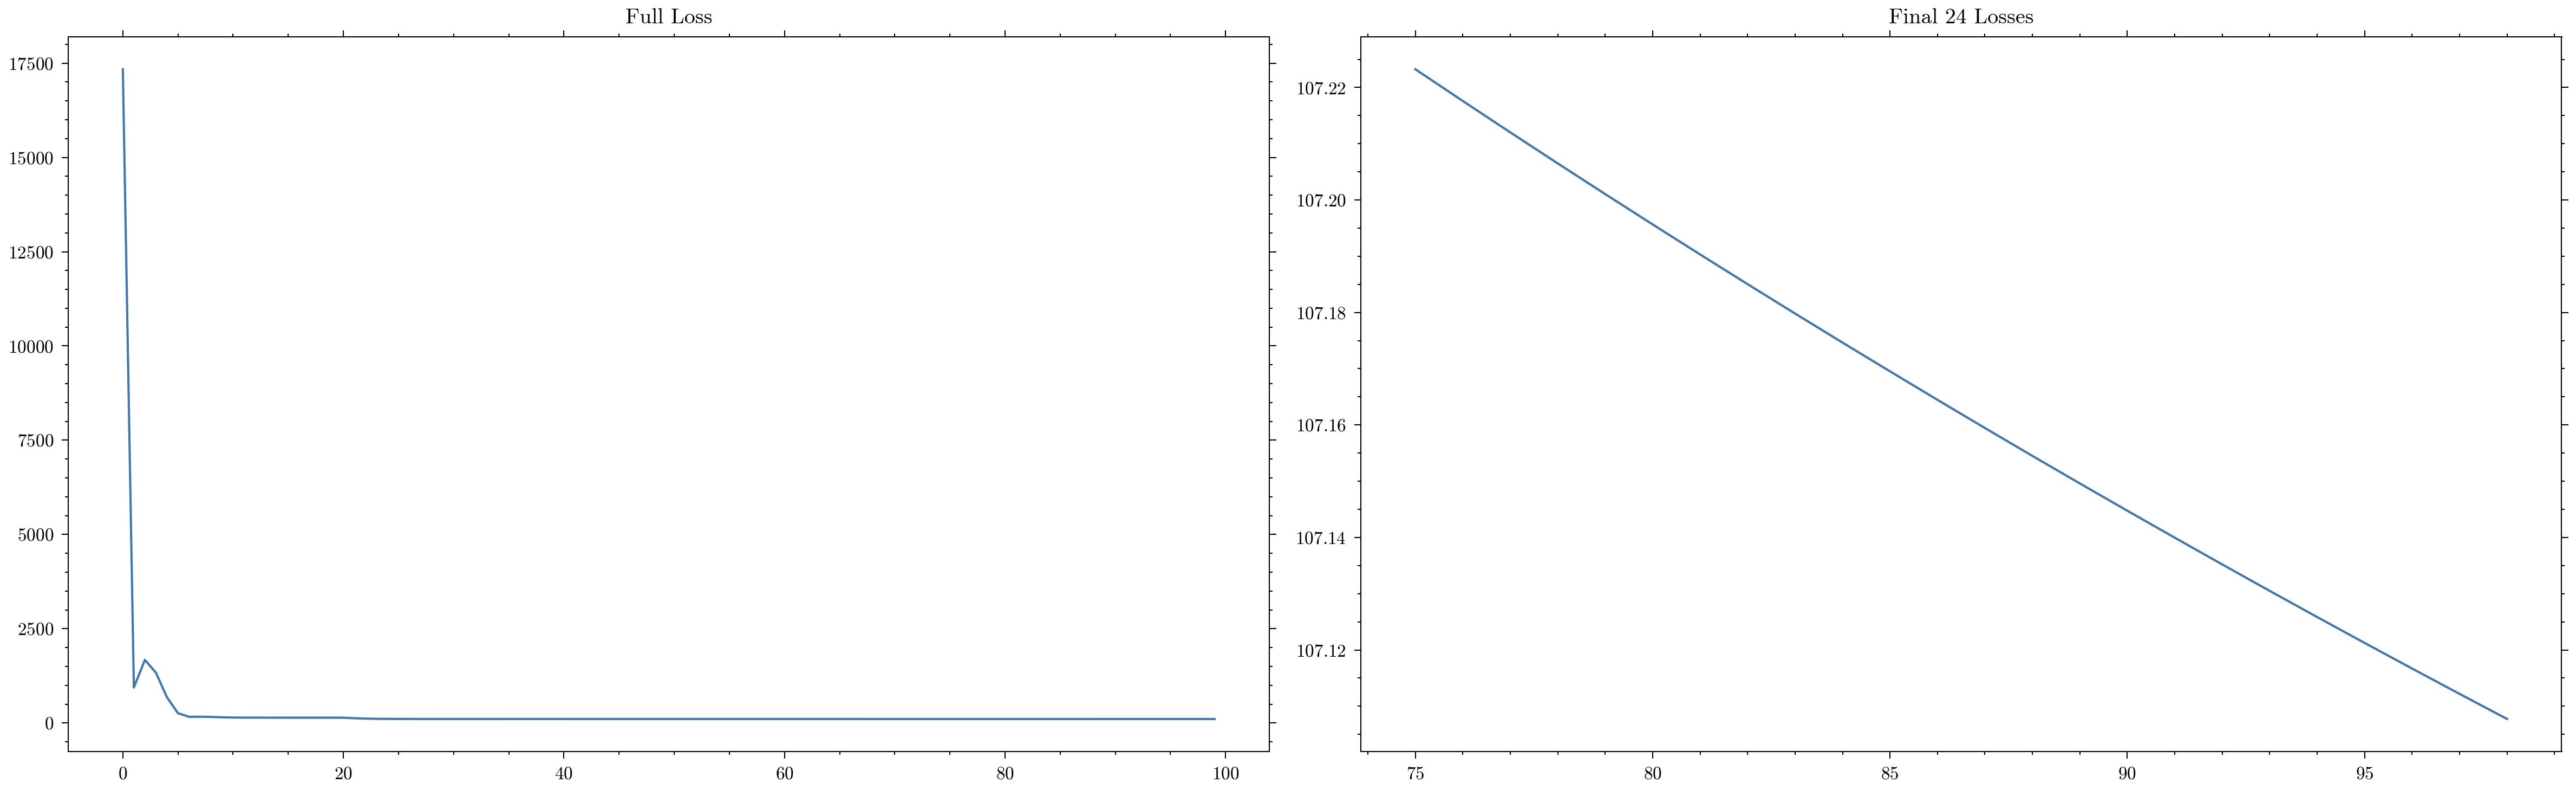

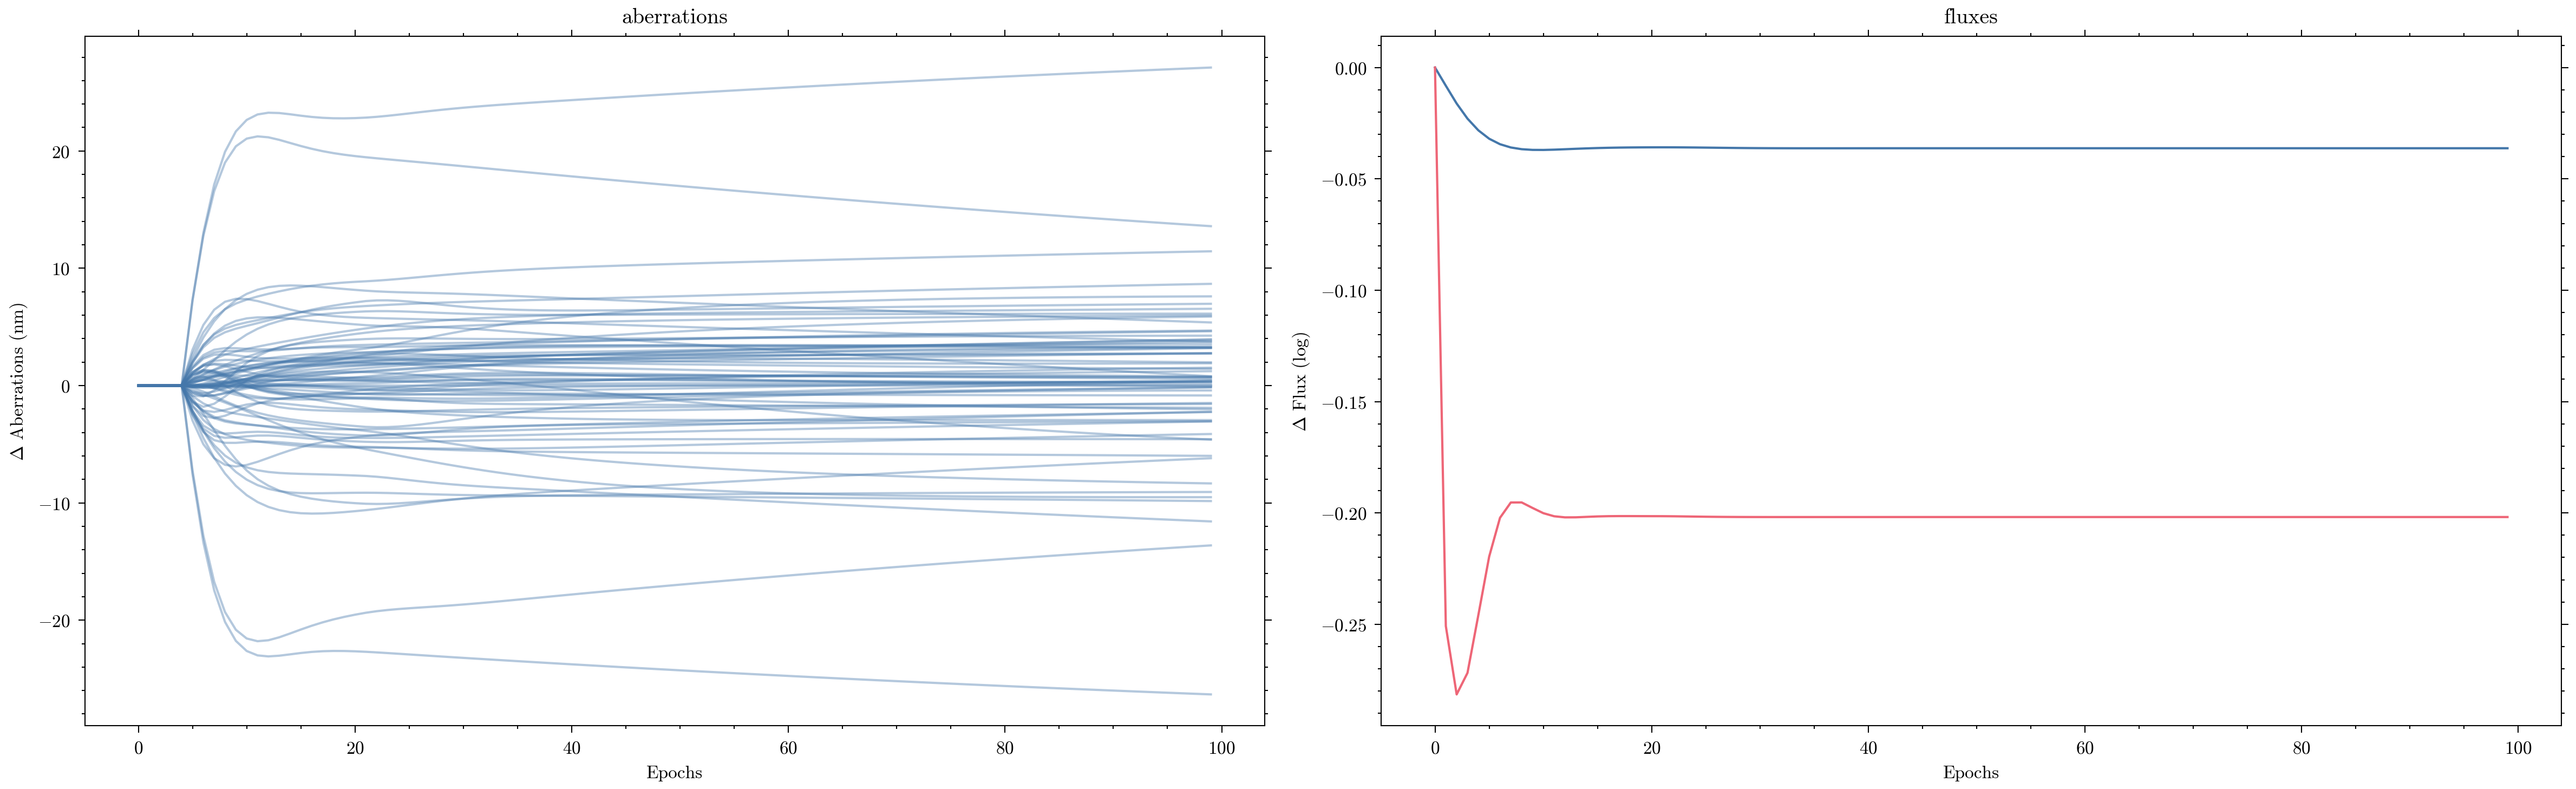

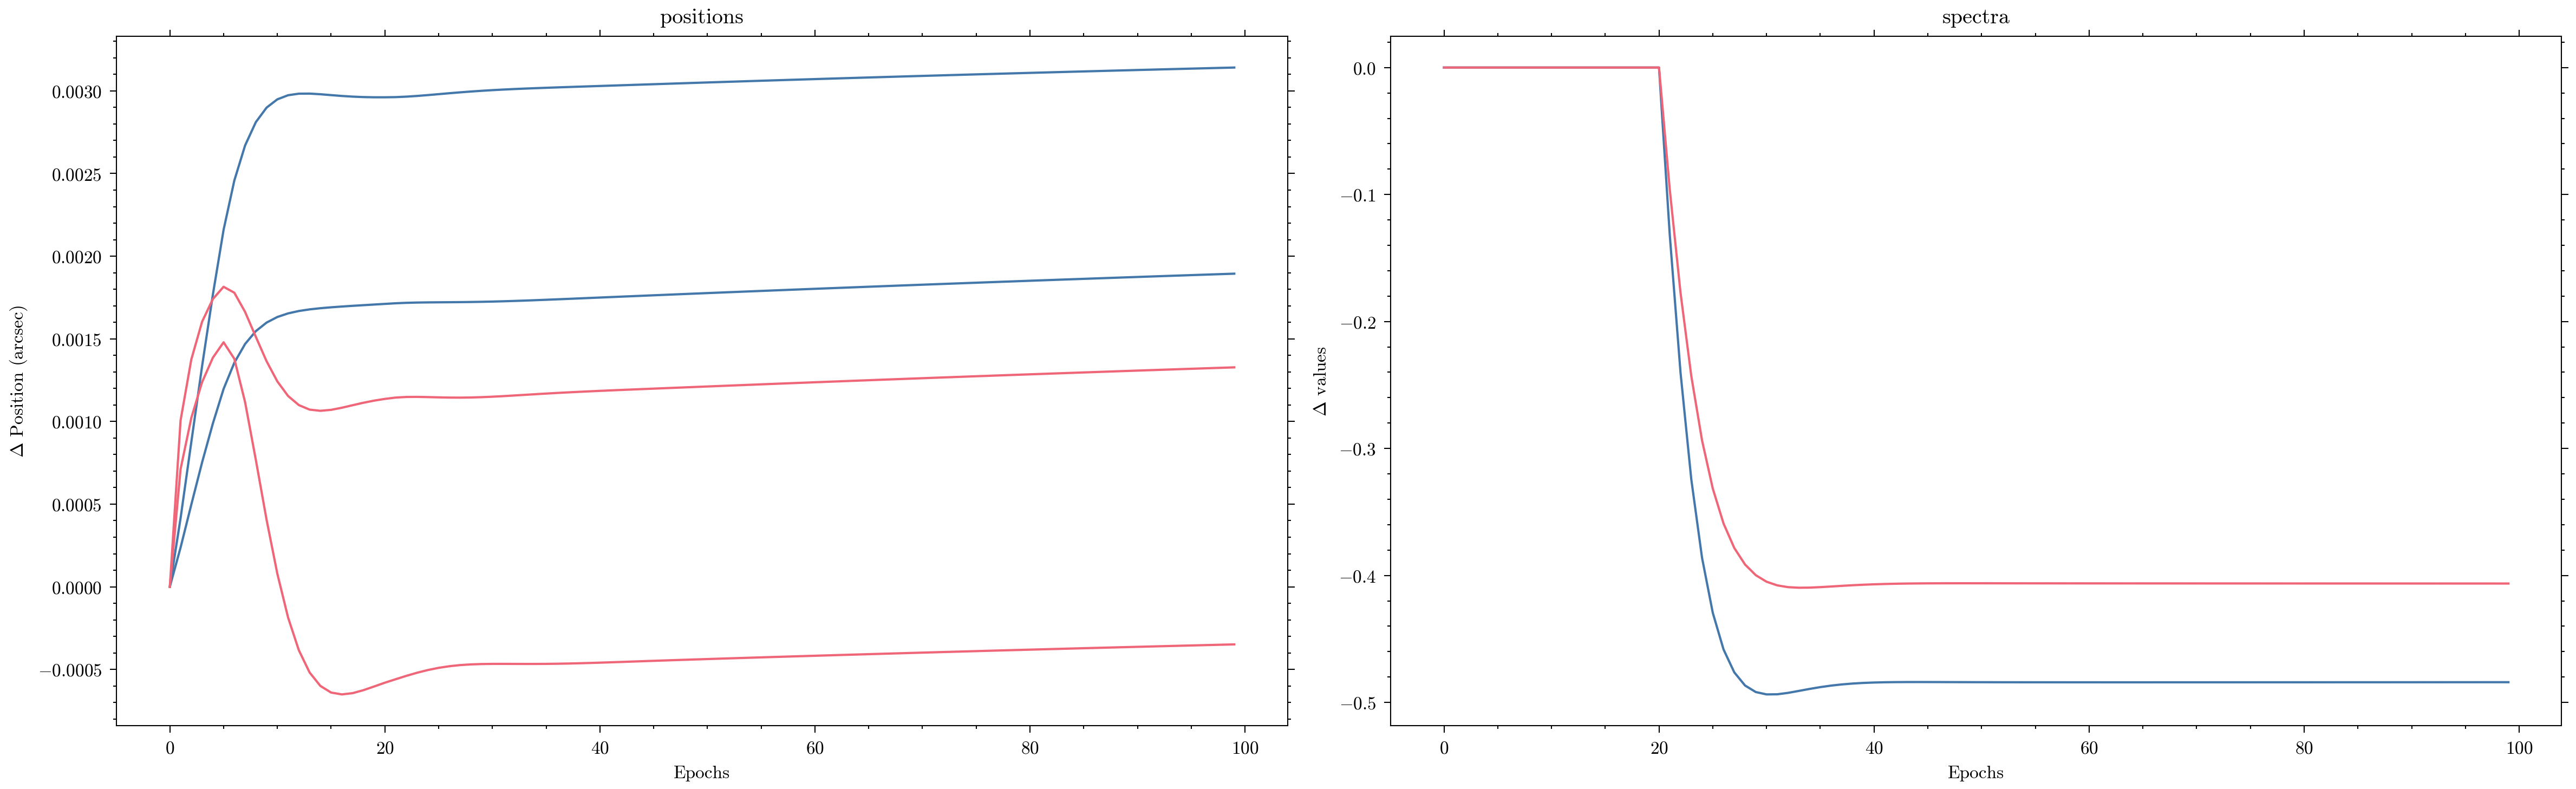

File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96



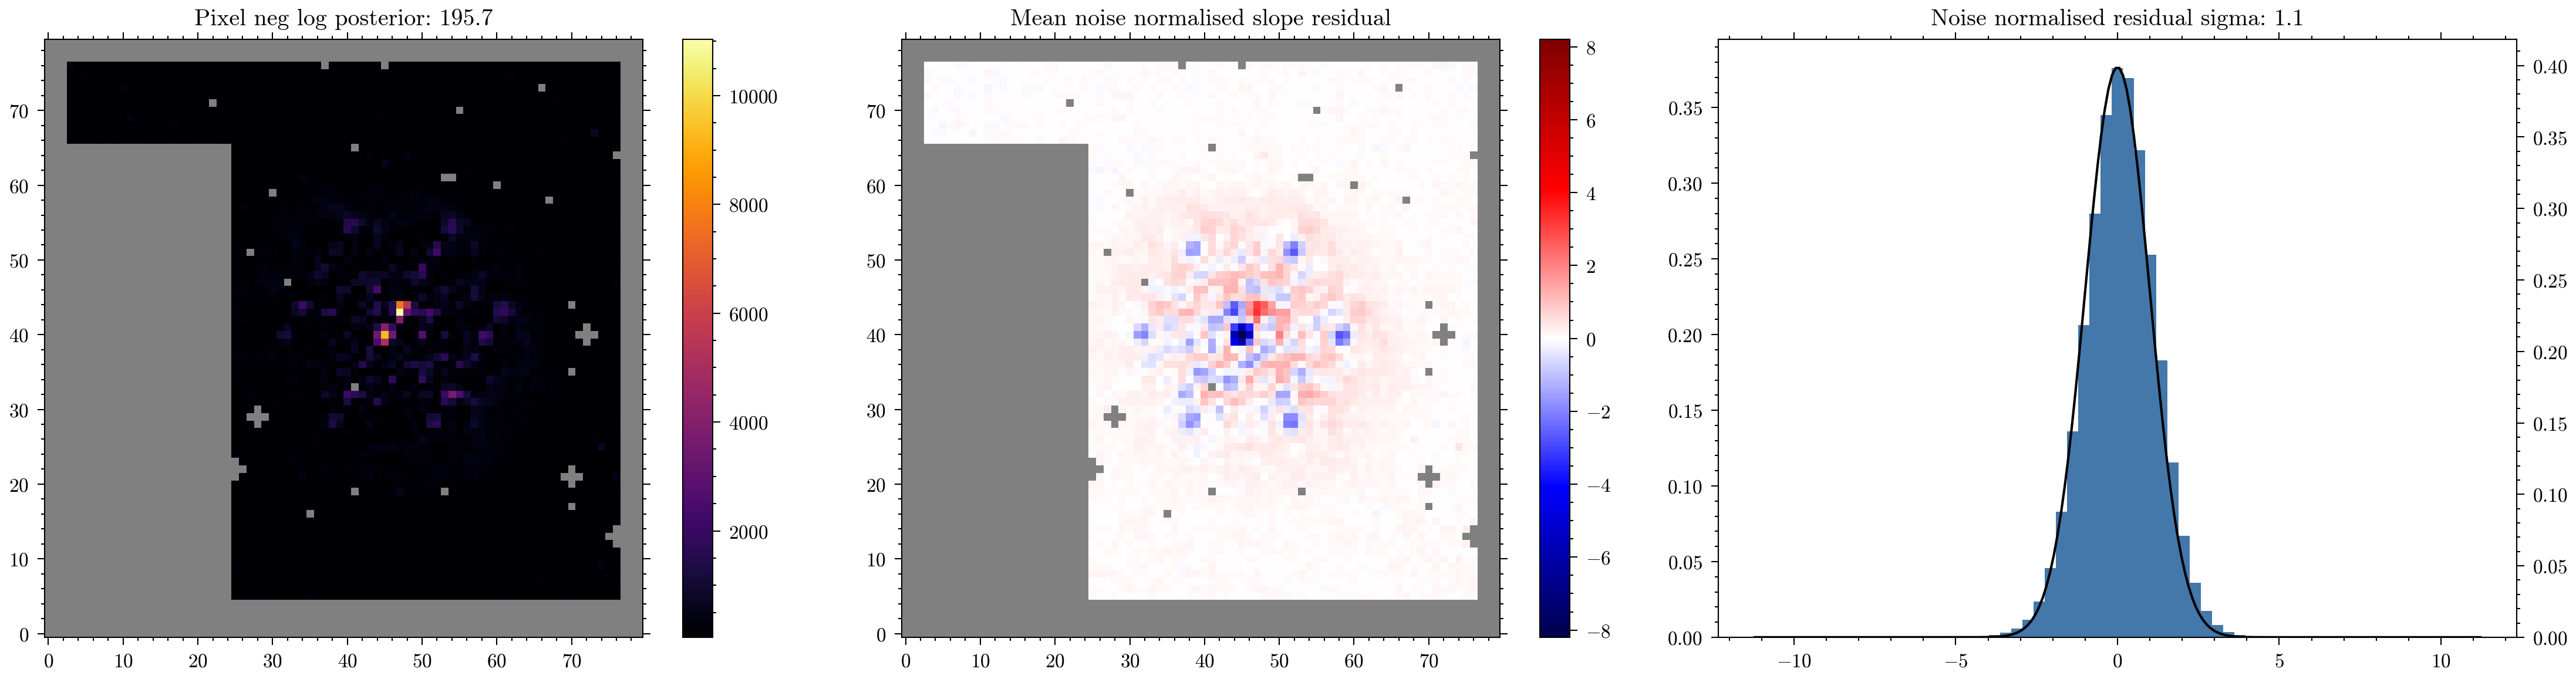

File 01242_004_02_03_1
Star HD 228337
Filter F480M
nints 418
ngroups 29



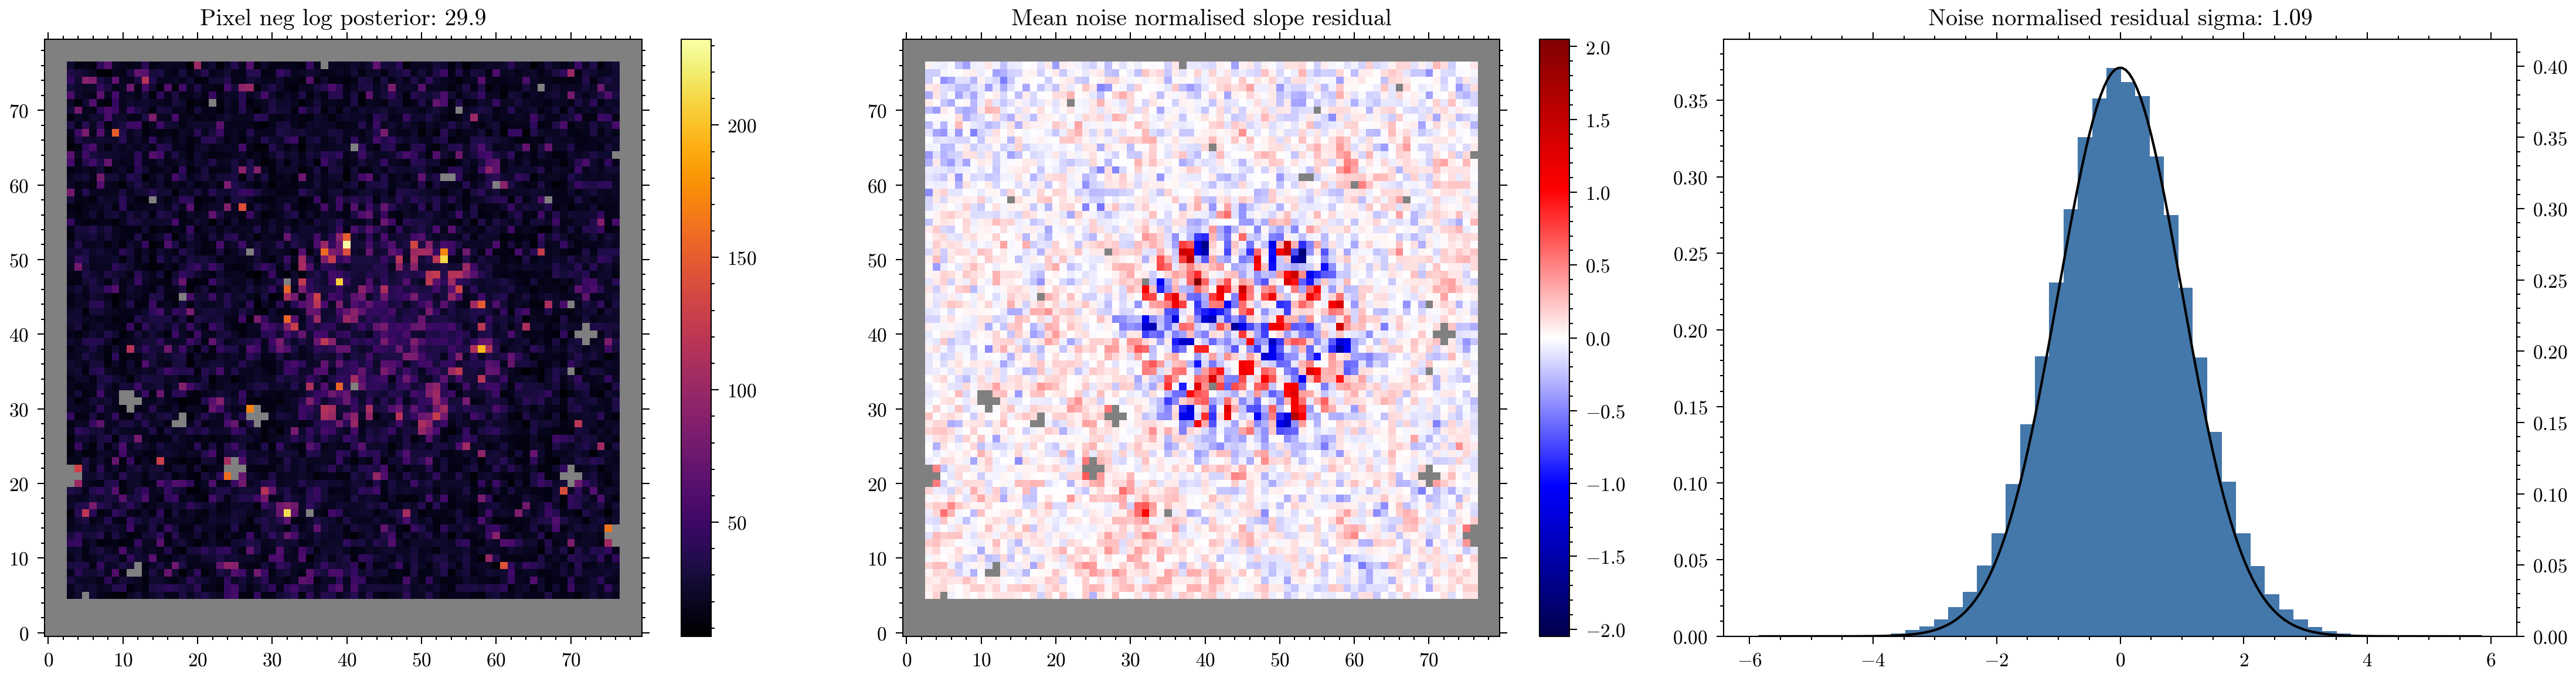

In [12]:
from dLux import utils as dlu


def eff_wavel(model, filt):
    wavels, weights = model.filters[filt]
    return np.dot(wavels, weights)


result_model = result.model


optics_diameter = 6.603464  # JWST aperture diameter in meters

for exp in fits:

    if exp.calibrator:
        continue
    dist = result_model.get_distribution(exp, rotate=False, with_star=False)
    fig, ax = plt.subplots(figsize=(6, 3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        # roll_angle_degrees=-exp.parang,
        norm=mpl.colors.PowerNorm(0.3),
        # norm=mpl.colors.PowerNorm(0.3, vmax=0.3),
        diff_lim=dlu.rad2arcsec(eff_wavel(model, exp.filter) / optics_diameter),
        # scale=1.5,
    )

    fig.colorbar(c0)

    ax.set(title=f"PDS70 - {exp.filter}")  #   xticks=ticks, yticks=ticks)
    ax.scatter([0], [0], marker="*", color="white", s=10)

    seps = 1e-3 * np.array([150.5, 218.4])
    pas = np.array([131.2, 270.0])
    xs = seps * np.cos(np.radians(pas))
    ys = seps * np.sin(np.radians(pas))
    ax.scatter(
        ys,
        xs,
        marker="o",
        alpha=0.9,
        s=20,
        facecolors="none",
        edgecolors="grey",
        linestyle="--",
        linewidths=0.7,
    )

    plt.tight_layout()
    plt.show()
    # plt.savefig(output_path + f"{exp.key}_dist.png", dpi=300)

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

    # model_slopes = exp(result.model)

    # for i in range(model_slopes.shape[0]):
    #     resids = np.where(~exp.badpix, model_slopes[i] - exp.slopes[i], np.nan)
    #     plt.imshow(resids, norm=mpl.colors.CenteredNorm(), cmap="seismic")
    #     plt.colorbar()
    #     plt.axis("off")
    #     plt.show()